In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import root

In [2]:
a = 0.3
eta = 5*10**(-3)
c = 9.65
d = 0.05 
kappa = 0.09
alpha = 0.01
alpha_0 = 0.03
beta = np.pi/2


def A(q): 
    return a * (np.sqrt(q**2 + eta**2) - eta)

def eps(q, Re):
    return (c/Re) * q

def v_r (q, Re):
    return d*Re*q

def u_dot (u, Re): 
    return (alpha+(beta**2)/Re)*(1-u)-beta*A(q)

def q_dot (q, Re): 
    return 1/2 *beta*A(q)- 2*alpha*q - eps(q,Re)

In [3]:
def u_nullcline(q, Re, beta, alpha, A):
    return 1 - (beta*Re*A(q))/(alpha*Re + beta**2)

def q_nullcline(q, Re, beta, alpha, A, eps):
    return (4*alpha*q + 2*eps(q, Re))/(beta*A(q))

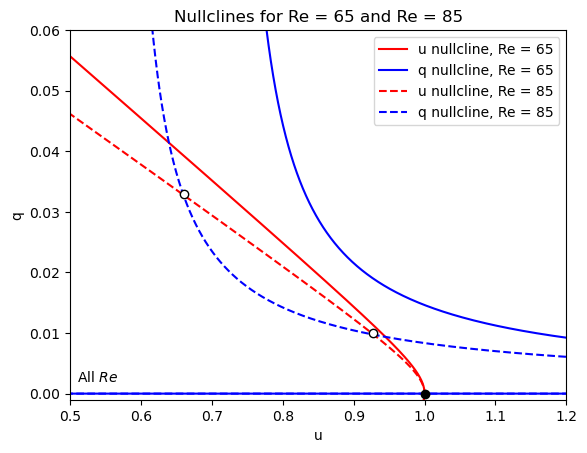

In [5]:
q_pos = np.linspace(0, 0.06, 800)
q_axis1 = np.linspace(-0.005, 0.06, 800)
u_vals = np.linspace(0.5, 1.1, 800)

Re = [65, 85] 

linesu = ['r', 'r--']
linesq = ['b', 'b--']

plt.figure
for i in range (2): 
    u_nc = u_nullcline(q_axis1, Re[i], beta, alpha, A)
    q_nc = q_nullcline(q_axis1, Re[i], beta, alpha, A, eps)
    plt.plot(u_nc, q_axis1, linesu[i], label = f'u nullcline, Re = {Re[i]}')
    plt.plot(q_nc, q_axis1, linesq[i], label = f'q nullcline, Re = {Re[i]}')
    plt.xlabel('u')
    plt.ylabel('q')

fp1x, fp1y = np.array([1]), np.array([0])
fp2x, fp2y = np.array([0.927, 0.66]), np.array([0.01, 0.033])
plt.scatter(fp1x, fp1y, c= 'k', zorder=2)
plt.scatter (fp2x, fp2y, c='w', edgecolors='k', zorder=2)

plt.title('Nullclines for Re = 65 and Re = 85')
plt.xlim(0.5, 1.2)
plt.ylim(-0.001, 0.06)
plt.text(0.51, 0.002, r"All $Re$")
plt.legend () 
plt.show()

In [ ]:
def q_Jacobian(q, u, Re, alpha, beta, a, eta): 
    dAdq = a*q/np.sqrt(q**2 + eta**2)
    deps_dq = c/Re


    J_11 = 1/2 * beta* u * dAdq - 2*alpha - deps_dq
    J_12 = 1/2 * beta * A(q)
    J_21 = -beta* dAdq 
    J_22 = - (alpha + (beta**2)/Re)

    J = np.array [[J_11, J_12], [J_21, J_22]]

    return J 

def bifurcation(q, u, Re_vals, alpha, beta, a, eta)
    q_stable = []
    q_unstable = []

    for Re in Re_vals: 
        for i in (len(q)-1):
            if q_dot(q[i],Re)*q_dot(q[i+1]) < 0 : 
                 u_i = q_nullcline(q[i], Re, beta, alpha, A, eps) #u is determined by the nullcline 
                 J = q_Jacobian(q[i], u_i, Re, alpha, beta, a, eta) 

                 eigvals = np.linalg.eigvals(J) 




In [ ]:
q_axis2 = np.linspace(-0.005, 0.04, 800)
Re_vals = np.linspace(60,100, 800)